****— Data Readiness & Quality Checks****

***Loading the CSV***

In [1]:
#importing the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("Week-5-Student-Scores 1.csv")
df.head()

,Student_ID,Gender,Subject,Study_Hours_per_Week,Attendance_Rate,Previous_Score,Quiz1,Quiz2,Quiz3,Final_Score
0,S1000,Female,English,7.3,0.88,70.0,30.0,46.0,58.0,45.0
1,S1001,Male,English,10.1,0.89,78.0,55.0,64.0,73.0,58.0
2,S1002,Male,Maths,9.4,0.98,50.0,53.0,47.0,55.0,44.0
3,S1003,Male,Maths,7.8,0.83,70.0,50.0,65.0,58.0,58.0
4,S1004,Female,Maths,5.5,0.92,75.0,49.0,28.0,51.0,47.0


**Checking the shape of the dataset**

In [2]:
df.shape

(121, 10)

**Checking the columns types in the dataset**

In [3]:
#column types
df.dtypes

Student_ID               object
Gender                   object
Subject                  object
Study_Hours_per_Week    float64
Attendance_Rate         float64
Previous_Score          float64
Quiz1                   float64
Quiz2                   float64
Quiz3                   float64
Final_Score             float64
dtype: object

**finding and handling missing values**

In [4]:
missing_table = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={"index": "Column", 0: "Missing Values"})
)

missing_table.style \
    .background_gradient(
        subset=["Missing Values"], cmap="Reds"
    ) \
    .format({"Missing Values": "{:.0f}"}) \
    .set_caption("🔍 Missing Values Summary") \
    .set_properties(**{
        "text-align": "center",
        "font-weight": "bold"
    })


,Column,Missing Values
0,Student_ID,0
1,Gender,0
2,Subject,0
3,Study_Hours_per_Week,5
4,Attendance_Rate,5
5,Previous_Score,0
6,Quiz1,0
7,Quiz2,5
8,Quiz3,0
9,Final_Score,0


In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Students Records",
        "Total Features",
        "Columns with Missing Values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isna().sum().gt(0).sum()
    ]
})

summary.style \
    .set_caption(" Student Dataset – Data Quality Overview") \
    .set_properties(**{
        "text-align": "center",
        "font-weight": "bold"
    }) \
    .background_gradient(cmap="Greens", subset=["Value"])


,Metric,Value
0,Total Students Records,121
1,Total Features,10
2,Columns with Missing Values,3


In [ ]:


# 🎯 Columns selected for missing value treatment
cols_to_impute = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Quiz2"
]

# 🧠 Median Imputation (robust to outliers)
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

# ✅ Verification: Missing values after imputation
missing_status = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "Feature", 0: "Missing Values"})
)

# 🎨 Styled Output
missing_status.style \
    .map(
        lambda x: (
            "background-color:#d4edda;"
            "color:#155724;"
            "font-weight:bold;"
        ) if x == 0 else (
            "background-color:#f8d7da;"
            "color:#721c24;"
            "font-weight:bold;"
        ),
        subset=["Missing Values"]
    ) \
    .set_caption("Student Dataset – Missing Values Successfully Imputed") \
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid #dee2e6"
    }) \
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#343a40"),
            ("color", "white"),
            ("text-align", "center")
        ]},
        {"selector": "caption", "props": [
            ("font-size", "16px"),
            ("font-weight", "bold")
        ]}
    ])


,Feature,Missing Values
0,Student_ID,0
1,Gender,0
2,Subject,0
3,Study_Hours_per_Week,0
4,Attendance_Rate,0
5,Previous_Score,0
6,Quiz1,0
7,Quiz2,0
8,Quiz3,0
9,Final_Score,0


**duplicate values**

In [ ]:
duplicate_count = df.duplicated().sum()
print(" STUDENT DATASET – DUPLICATE CHECK\n")
print(f" Duplicate Records Found : {duplicate_count}")



📘 STUDENT DATASET – DUPLICATE CHECK

🔁 Duplicate Records Found : 1


In [8]:
df_before = len(df)

df = df.drop_duplicates()

df_after = len(df)
removed = df_before - df_after


In [ ]:
print("\n✅ DUPLICATE HANDLING SUMMARY\n")
print(f" Records Before Cleaning : {df_before}")
print(f"🗑 Duplicate Records Removed : {removed}")
print(f" Records After Cleaning  : {df_after}")

if removed == 0:
    print("\n  No duplicate records found. Dataset is already clean!")
else:
    print("\n  Duplicate records successfully removed!")



✅ DUPLICATE HANDLING SUMMARY

📊 Records Before Cleaning : 121
🗑 Duplicate Records Removed : 1
📘 Records After Cleaning  : 120

🎉  Duplicate records successfully removed!


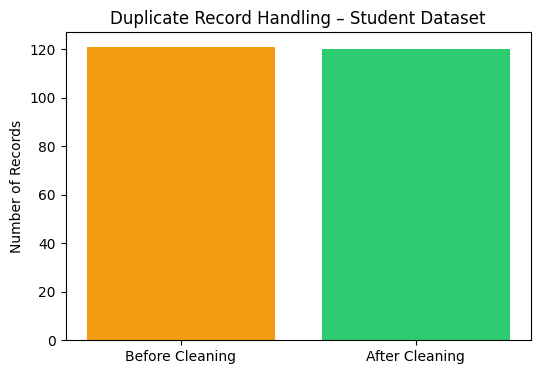

In [10]:
values = [df_before, df_after]
labels = ["Before Cleaning", "After Cleaning"]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=["#f39c12", "#2ecc71"])
plt.title("Duplicate Record Handling – Student Dataset")
plt.ylabel("Number of Records")
plt.show()


##  Data Diagnostics Summary

|  Data Quality Check                 |  Result                                      |
|--------------------------------------|-----------------------------------------------|
|  Total Records                     | *Unchanged after cleaning*                    |
|  Columns with Missing Values (before) | Study_Hours_per_Week, Attendance_Rate, Quiz2 |
|  Missing Values Handling           | Median imputation                             |
|  Missing Values (after)            | 0 across all columns                          |
|  Duplicate Records                 | Identified and removed                        |
|  Final Dataset Status              | Complete & duplicate-free                     |


## Data Cleaning Decisions (Justification)

-  **Missing values imputed using median**  
  Preserved all student records and avoided reducing dataset size.

- **Median chosen over mean**  
  More robust to outliers, especially for academic scores and attendance-related features.

-  **No rows dropped**  
  Missing values were limited and imputable without introducing significant bias.

-  **Duplicate records removed**  
  Ensured each student is represented only once.

- **Final checks completed**  
  Zero missing values and no duplicates confirmed — dataset is now complete and ready for analysis and modeling.


****Question 2: Descriptive statistics table (compact)****

In [11]:

# Select numeric columns
numeric_cols = ["Study_Hours_per_Week", "Attendance_Rate", "Previous_Score", 
                "Quiz1", "Quiz2", "Quiz3", "Final_Score"]

# Generate descriptive statistics
desc = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T

# Keep only relevant columns and rename
desc = desc[["mean", "50%", "std", "min", "25%", "75%", "max"]].rename(
    columns={"50%": "median", "25%": "25th_pct", "75%": "75th_pct"}
)

desc.style.background_gradient(cmap="Blues").set_caption("📊 Numeric Descriptive Statistics")



,mean,median,std,min,25th_pct,75th_pct,max
Study_Hours_per_Week,8.034167,8.200000,2.922285,0.000000,6.000000,9.900000,19.600000
Attendance_Rate,0.887167,0.890000,0.065762,0.740000,0.837500,0.930000,1.000000
Previous_Score,60.058333,60.000000,12.115894,34.000000,51.000000,69.000000,98.000000
Quiz1,48.475000,48.500000,12.563762,18.000000,40.000000,55.250000,84.000000
Quiz2,49.754167,49.500000,13.360860,15.000000,42.000000,58.000000,81.000000
Quiz3,51.966667,52.000000,11.283165,16.000000,44.000000,61.000000,77.000000
Final_Score,48.141667,47.000000,9.497718,23.000000,41.750000,55.000000,73.000000


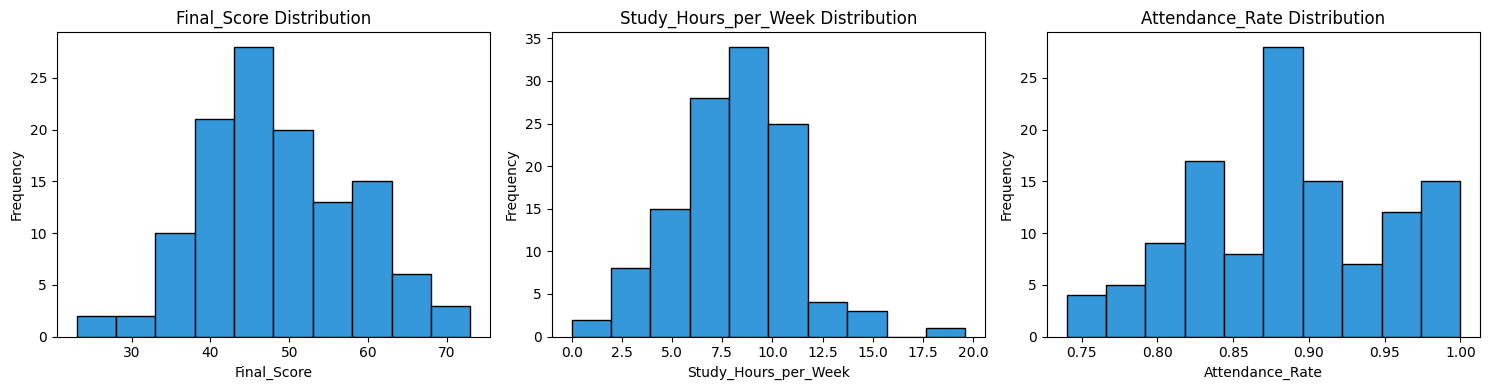

In [12]:
cols_to_plot = ["Final_Score", "Study_Hours_per_Week", "Attendance_Rate"]
plt.figure(figsize=(15,4))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[col], bins=10, color="#3498db", edgecolor="black")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


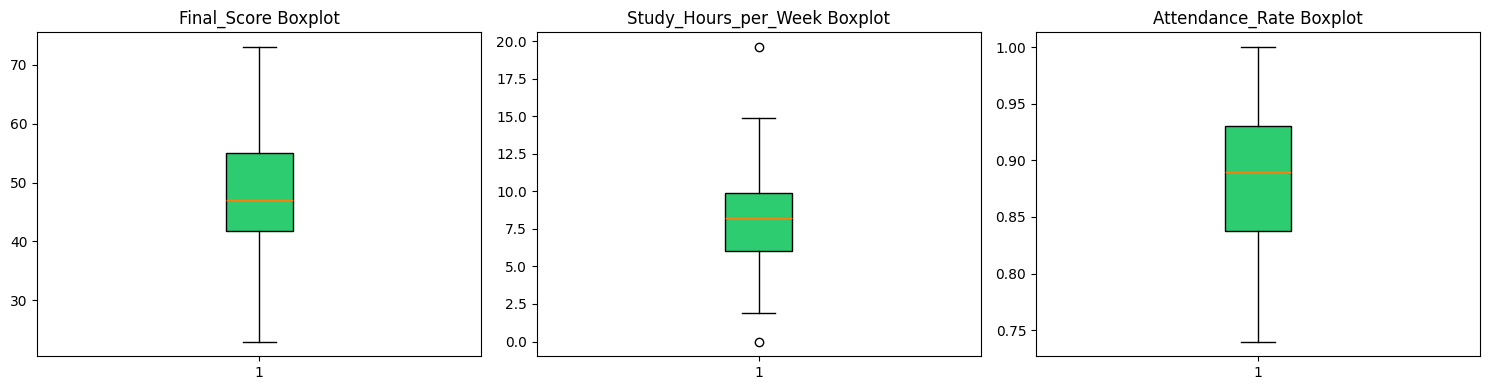

In [13]:
plt.figure(figsize=(15,4))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#2ecc71"))
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()


##  Data Distribution Insights

-  **Final_Score**  
  Appears fairly **symmetric** with few extreme values, suggesting **consistent student performance** overall.

- **Study_Hours_per_Week**  
  Shows **right-skewness**, with some students studying much more than the majority. This indicates **high variability in study habits**.

-  **Attendance_Rate**  
  Exhibits a slight **left-skew**, with most students attending regularly but a few **low-attendance cases** present.

-  **Outliers**  
  Visible in **Study_Hours_per_Week** and **Attendance_Rate** boxplots. These may reflect **exceptional but valid cases**.

- **Implications of Skewness**  
  Median values may be more **representative than the mean** for certain analyses due to skewed distributions.

- **Overall**  
  Distributions are suitable for modeling, but **skewness and outliers** should be considered for **transformations or robust models**.
